## Activity Title - Image Noise Addition and Removal

Loaded: cameraman.png, shape=(256, 256)


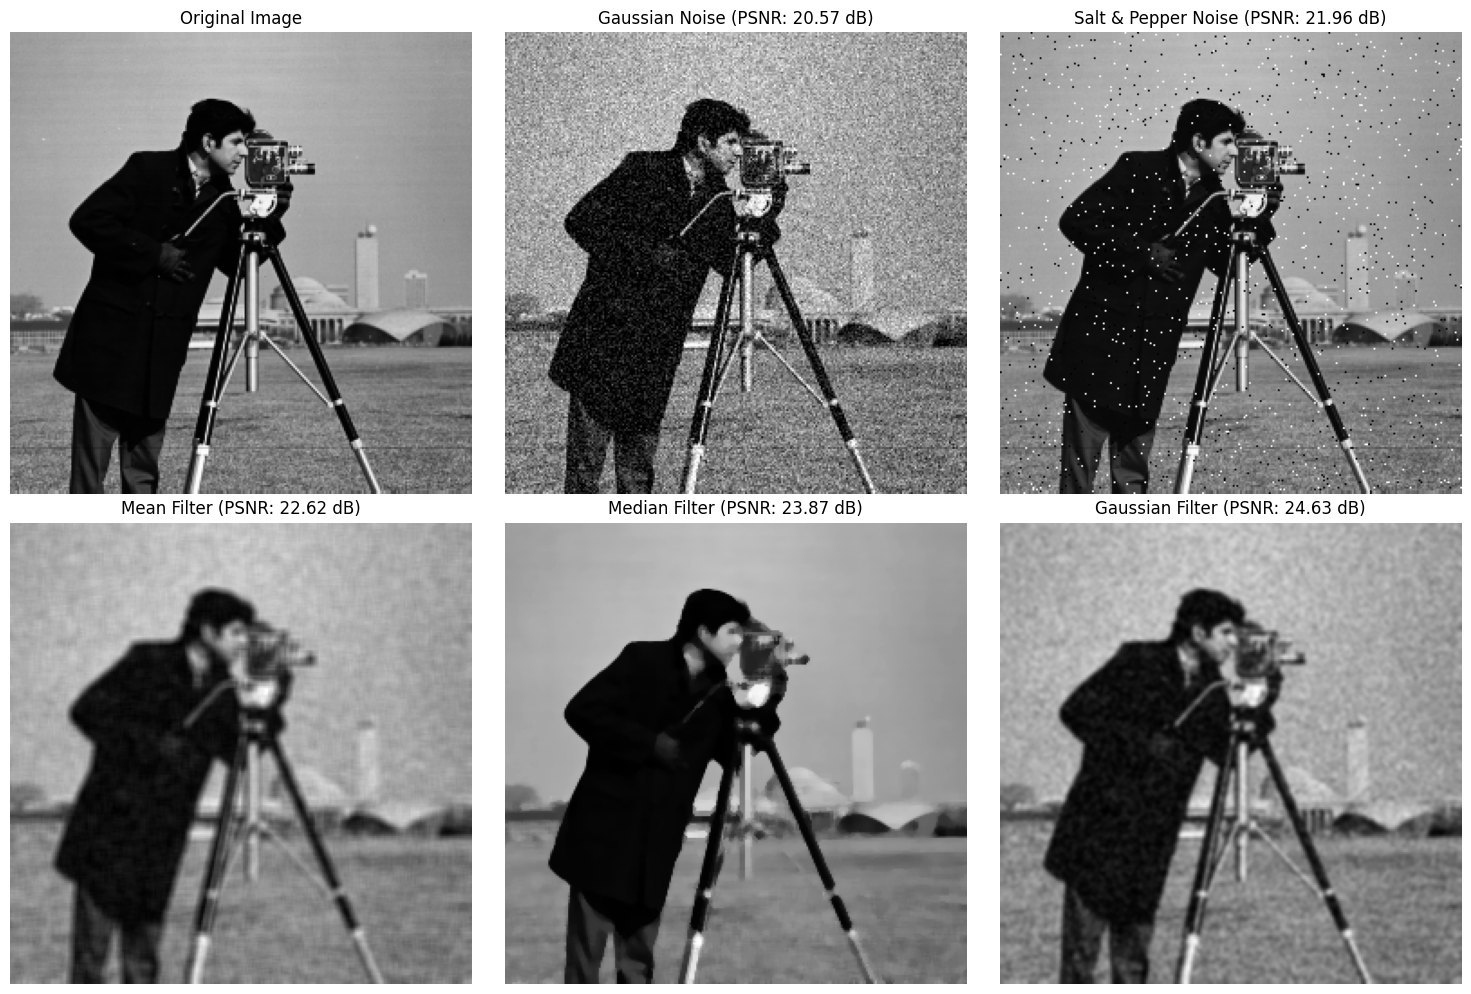

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

file_name = 'cameraman.png'
img = cv2.imread(file_name)

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(f"Loaded: {file_name}, shape={img.shape}")

# ---------- Metric ----------
def psnr(img1, img2):
    img1_f = img1.astype(np.float64)
    img2_f = img2.astype(np.float64)
    mse = np.mean((img1_f - img2_f) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# ---------- Add Noise ----------
# (A) Gaussian Noise — FIXED (no uint8 wrap)
gaus_sigma = 25
gaussian_noise = np.random.normal(0, gaus_sigma, img.shape)
noisy_gaussian = img.astype(np.float64) + gaussian_noise
noisy_gaussian = np.clip(noisy_gaussian, 0, 255).astype(np.uint8)

# (B) Salt & Pepper
salt_pepper = img.copy()
prob = 0.02
rand = np.random.rand(*img.shape)
salt_pepper[rand < prob/2] = 0
salt_pepper[rand > 1 - prob/2] = 255

# ---------- Filters ----------
# For Gaussian noise
mean_filter_gaussian = cv2.blur(noisy_gaussian, (5, 5))
gaussian_filter_gaussian = cv2.GaussianBlur(noisy_gaussian, (5, 5), 0)

# For Salt & Pepper
median_filter_sp = cv2.medianBlur(salt_pepper, 5)

# ---------- Save Outputs (deliverable) ----------
cv2.imwrite('noisy_gaussian.png', noisy_gaussian)
cv2.imwrite('noisy_salt_pepper.png', salt_pepper)
cv2.imwrite('restored_mean.png', mean_filter_gaussian)
cv2.imwrite('restored_gaussian.png', gaussian_filter_gaussian)
cv2.imwrite('restored_median.png', median_filter_sp)  # closest to “noise-free”







# ---------- Visualize ----------
images = [
    img,
    noisy_gaussian,
    salt_pepper,
    mean_filter_gaussian,
    median_filter_sp,
    gaussian_filter_gaussian
]

titles = [
    'Original Image',
    f'Gaussian Noise (PSNR: {psnr(img, noisy_gaussian):.2f} dB)',
    f'Salt & Pepper Noise (PSNR: {psnr(img, salt_pepper):.2f} dB)',
    f'Mean Filter (PSNR: {psnr(img, mean_filter_gaussian):.2f} dB)',
    f'Median Filter (PSNR: {psnr(img, median_filter_sp):.2f} dB)',
    f'Gaussian Filter (PSNR: {psnr(img, gaussian_filter_gaussian):.2f} dB)'
]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()